# Sid — Clustering

Unsupervised clustering to find natural groups of counties
based on demographic and socioeconomic features.

**Input:** `../data/processed/model_ready_dataset.csv`
**Models:** K-Means Clustering

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", None)

### (2) Load dataset

In [2]:
df = pd.read_csv(
    "../data/processed/model_ready_dataset.csv",
    dtype={"county_fips": str},
    low_memory=False
)

features = [
    "higher_ed_rate", "poverty_rate", "unemployment_rate",
    "white_pct", "black_pct", "asian_pct",
    "median_income", "log_population", "housing_density"
]

model_df = df[features + ["party_winner", "dem_vote_share",
                           "state", "county_name"]].dropna()

print(f"Shape: {model_df.shape}")

Shape: (3114, 13)


### (3) Scale features

In [3]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(model_df[features])
print("Scaling done.")

Scaling done.


### (4) Find optimal clusters — Elbow method

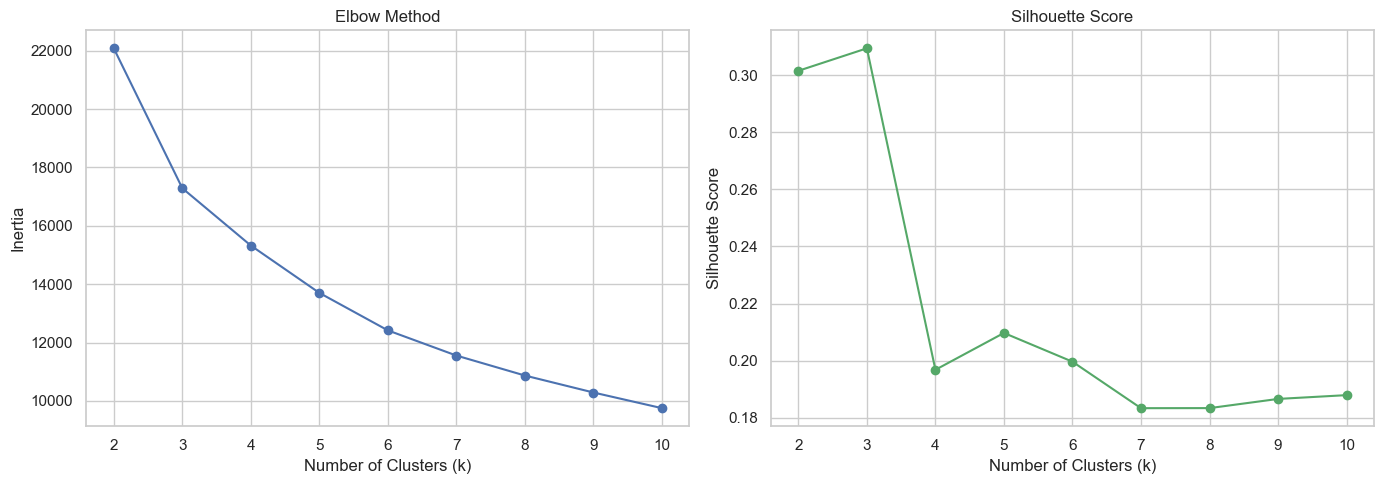


Silhouette scores:
  k=2: 0.3015
  k=3: 0.3094
  k=4: 0.1968
  k=5: 0.2097
  k=6: 0.1996
  k=7: 0.1834
  k=8: 0.1834
  k=9: 0.1866
  k=10: 0.1879


In [4]:
inertias = []
silhouettes = []
K = range(2, 11)

for k in K:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X_scaled)
    inertias.append(km.inertia_)
    silhouettes.append(silhouette_score(X_scaled, km.labels_))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(K, inertias, "bo-")
axes[0].set_xlabel("Number of Clusters (k)")
axes[0].set_ylabel("Inertia")
axes[0].set_title("Elbow Method")

axes[1].plot(K, silhouettes, "go-")
axes[1].set_xlabel("Number of Clusters (k)")
axes[1].set_ylabel("Silhouette Score")
axes[1].set_title("Silhouette Score")

plt.tight_layout()
plt.show()

print("\nSilhouette scores:")
for k, s in zip(K, silhouettes):
    print(f"  k={k}: {s:.4f}")

### (5) Train final K-Means with k=3

In [5]:
km = KMeans(n_clusters=3, random_state=42, n_init=10)
model_df = model_df.copy()
model_df["cluster"] = km.fit_predict(X_scaled)

print("Cluster distribution:")
print(model_df["cluster"].value_counts().sort_index())

Cluster distribution:
cluster
0     517
1     554
2    2043
Name: count, dtype: int64


### (6) Cluster profiles

In [6]:
profile = model_df.groupby("cluster")[
    features + ["dem_vote_share", "party_winner"]
].mean().round(3)

display(profile)

,higher_ed_rate,poverty_rate,unemployment_rate,white_pct,black_pct,asian_pct,median_income,log_population,housing_density,dem_vote_share,party_winner
cluster,,,,,,,,,,,
0,0.256,0.099,0.046,0.767,0.095,0.048,75840.284,12.302,0.424,0.505,0.532
1,0.113,0.217,0.079,0.580,0.311,0.008,41595.953,10.114,0.474,0.422,0.325
2,0.143,0.130,0.045,0.899,0.030,0.007,53234.284,9.824,0.518,0.265,0.041


### (7) Visualize clusters with PCA

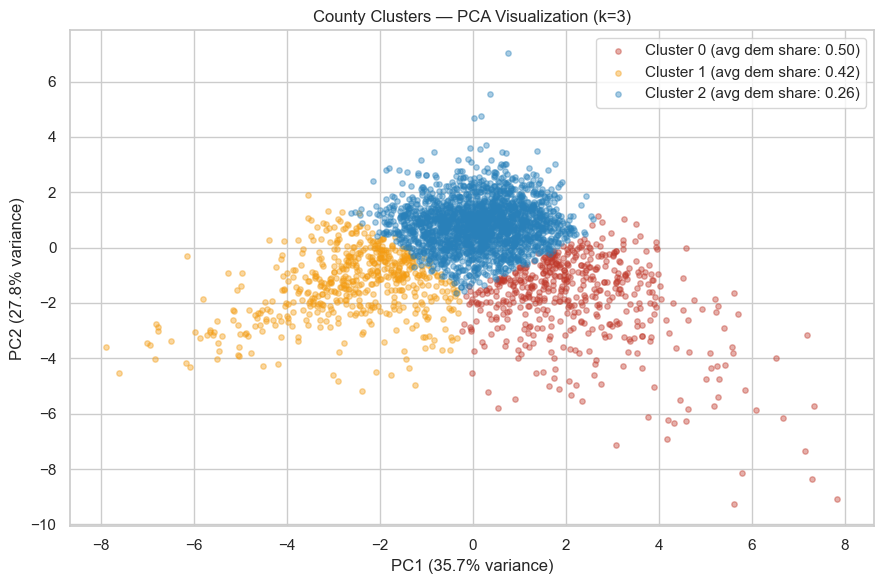


Total variance explained by 2 components: 63.5%


In [7]:
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled)

plt.figure(figsize=(9, 6))
colors = ["#c0392b", "#f39c12", "#2980b9"]

for cluster in range(3):
    mask = model_df["cluster"] == cluster
    avg_share = model_df.loc[mask, "dem_vote_share"].mean()
    plt.scatter(
        X_pca[mask, 0], X_pca[mask, 1],
        c=colors[cluster], alpha=0.4, s=15,
        label=f"Cluster {cluster} (avg dem share: {avg_share:.2f})"
    )

plt.title("County Clusters — PCA Visualization (k=3)")
plt.xlabel(f"PC1 ({pca.explained_variance_ratio_[0]*100:.1f}% variance)")
plt.ylabel(f"PC2 ({pca.explained_variance_ratio_[1]*100:.1f}% variance)")
plt.legend()
plt.tight_layout()
plt.show()

print(f"\nTotal variance explained by 2 components: "
      f"{sum(pca.explained_variance_ratio_)*100:.1f}%")

### (8) Cluster voting breakdown

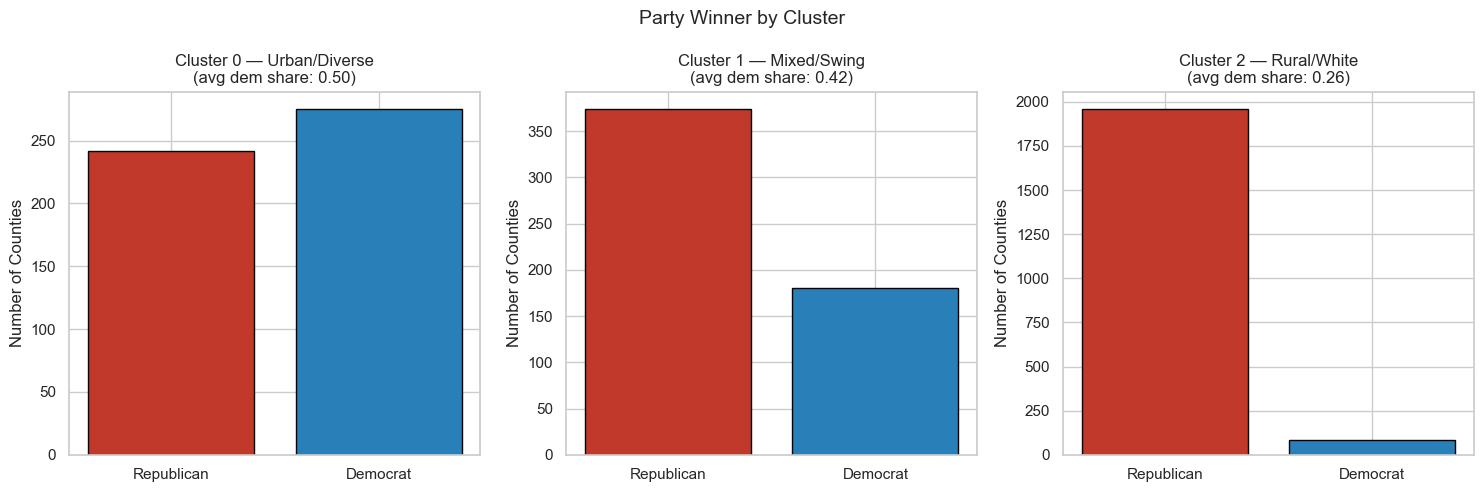

In [8]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
colors = ["#c0392b", "#f39c12", "#2980b9"]
labels = ["Urban/Diverse", "Mixed/Swing", "Rural/White"]

for cluster in range(3):
    mask = model_df["cluster"] == cluster
    counts = model_df.loc[mask, "party_winner"].value_counts()
    rep = counts.get(0, 0)
    dem = counts.get(1, 0)
    axes[cluster].bar(["Republican", "Democrat"],
                      [rep, dem],
                      color=["#c0392b", "#2980b9"],
                      edgecolor="black")
    axes[cluster].set_title(f"Cluster {cluster} — {labels[cluster]}\n"
                            f"(avg dem share: {model_df.loc[mask,'dem_vote_share'].mean():.2f})")
    axes[cluster].set_ylabel("Number of Counties")

plt.suptitle("Party Winner by Cluster", fontsize=14)
plt.tight_layout()
plt.show()

### (9) Summary

In [10]:
print("=" * 50)
print("CLUSTERING SUMMARY")
print("=" * 50)
print("Optimal k: 3 (highest silhouette score 0.309)")
print()
print("Cluster 0 — Urban/Diverse")
print("  High education, high Asian%, competitive")
print("  Avg dem vote share: 0.50")
print()
print("Cluster 1 — Mixed/Swing")
print("  High Black%, moderate income")
print("  Avg dem vote share: 0.42")
print()
print("Cluster 2 — Rural/White")
print("  High white%, low education, low income")
print("  Avg dem vote share: 0.26")
print()
print("Key insight: Demographic clusters naturally")
print("align with voting patterns without using")
print("any election data during clustering.")
print("=" * 50)

CLUSTERING SUMMARY
Optimal k: 3 (highest silhouette score 0.309)

Cluster 0 — Urban/Diverse
  High education, high Asian%, competitive
  Avg dem vote share: 0.50

Cluster 1 — Mixed/Swing
  High Black%, moderate income
  Avg dem vote share: 0.42

Cluster 2 — Rural/White
  High white%, low education, low income
  Avg dem vote share: 0.26

Key insight: Demographic clusters naturally
align with voting patterns without using
any election data during clustering.
